In [10]:
import os

os.makedirs('co2-analysis', exist_ok=True)

Analysis complete. Graphic saved as 'co2_emissions_trend.png'.


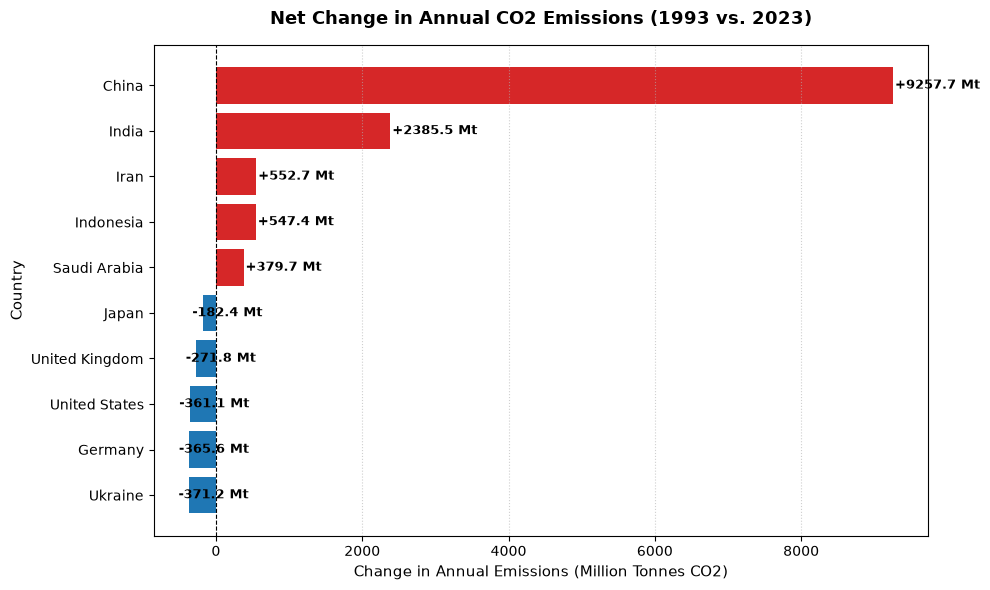

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fetch live global CO2 dataset from Our World in Data
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

# 2. Filter for valid individual countries (exclude regional aggregates)
df_countries = df[df['iso_code'].notna() & ~df['iso_code'].str.startswith('OWID_', na=False)].copy()

# Select 30-year timeframe
start_year, end_year = 1993, 2023
df_filtered = df_countries[df_countries['year'].isin([start_year, end_year])]

# Pivot table to calculate net changes
pivot = df_filtered.pivot(index='country', columns='year', values='co2').dropna()
pivot['abs_change'] = pivot[end_year] - pivot[start_year]
pivot['pct_change'] = ((pivot[end_year] - pivot[start_year]) / pivot[start_year]) * 100

# Filter out baseline micro-emitters (<10 Mt CO2 in 1993) to remove noise from tiny countries
pivot_valid = pivot[pivot[start_year] >= 10].copy()

# Extract top 5 absolute increasers and decreasers
top_rising = pivot_valid.sort_values('abs_change', ascending=False).head(5)
top_falling = pivot_valid.sort_values('abs_change', ascending=True).head(5)
combined = pd.concat([top_falling, top_rising]).sort_values('abs_change')

# 3. Generate Chart
plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if x < 0 else '#d62728' for x in combined['abs_change']]

bars = plt.barh(combined.index, combined['abs_change'], color=colors)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Net Change in Annual CO2 Emissions (1993 vs. 2023)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Change in Annual Emissions (Million Tonnes CO2)', fontsize=11)
plt.ylabel('Country', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Data labels
for bar in bars:
    width = bar.get_width()
    offset = 25 if width >= 0 else -140
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:+.1f} Mt', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('co2_emissions_trend.png', dpi=300)
print("Analysis complete. Graphic saved as 'co2_emissions_trend.png'.")

In [12]:
import os

print("Current Working Folder Path:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Working Folder Path: /home/jovyan/climate-module-P0MPH
Files in this folder: ['Sea Ice.ipynb', '.github', '.git', '.kilo', '.gitignore', 'requirements.txt', 'README.md', 'climate_files', 'climate.html', 'climate.ipynb', 'LICENSE', 'co2_emissions_trend.png', '.devcontainer', 'benchmark.md', 'co2-analysis', 'rubric.md']


In [13]:
pwd

'/home/jovyan/climate-module-P0MPH'